# 02 — Radial Distribution (Free Vortex)

**Purpose:** Extend the meanline result spanwise using the free-vortex law
(r·Cθ = const). Verify that De Haller and Lieblein DF stay within limits
at every radial station from hub to tip.

**Inputs:** `design_point.json` written by notebook 01.

**References:** Dixon & Hall (2014) Ch. 6; Lieblein et al. (1953) NACA RM E53D01.

In [1]:
import sys, pathlib, json as _json, math

# Locate repo root (the directory that contains src/)
_here = pathlib.Path.cwd()
_root = next(
    (p for p in [_here, *_here.parents] if (p / 'src').is_dir()),
    _here,
)
sys.path.insert(0, str(_root))
pathlib.Path(_root / 'figures').mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.meanline import meanline_analysis
from src.radial   import free_vortex
from src.plotting import plot_radial

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
print('Imports OK')

Imports OK


## 1. Load design point from notebook 01

In [2]:
_dp_path = _root / 'design_point.json'
if not _dp_path.exists():
    raise FileNotFoundError('design_point.json not found — run notebook 01 first.')

dp    = _json.loads(_dp_path.read_text())
D_tip = dp['D_tip']
N     = dp['N_RPM']
PR    = dp['PR']
eta   = dp['eta_is']
nu    = dp['nu']
phi   = dp['phi']

res = meanline_analysis(D_tip, N, PR, eta, nu=nu, phi=phi)

print('Loaded: D_tip=%g mm  N=%g RPM  PR=%g  nu=%g  phi=%g' % (D_tip*1000, N, PR, nu, phi))
print('Mean radius  : %.1f mm' % (res['r_mean']*1000))
print('Blade height : %.1f mm' % res['h_mm'])
print('psi=%.4f   DH=%.4f   P=%.1f kW' % (res['psi'], res['De_Haller'], res['P_shaft_kW']))

Loaded: D_tip=900 mm  N=3500 RPM  PR=1.1  nu=0.75  phi=0.725
Mean radius  : 393.8 mm
Blade height : 112.5 mm
psi=0.4514   DH=0.7361   P=335.4 kW


## 2. Mid-span solidity (mirrors igv.py auto-sizing)

In [3]:
r_mean    = res['r_mean']
h         = res['r_tip'] - res['r_hub']
AR        = 1.5
B         = int(math.ceil(2 * math.pi * r_mean * 1.1 * AR / h))
if B % 2 == 0:
    B += 1
chord_mid = h / AR
pitch_mid = 2 * math.pi * r_mean / B
sigma_mid = chord_mid / pitch_mid

print('B=%d blades   chord_mid=%.1f mm   sigma_mid=%.3f' % (B, chord_mid*1000, sigma_mid))

B=37 blades   chord_mid=75.0 mm   sigma_mid=1.122


## 3. Free-vortex radial distribution

In [4]:
rad = free_vortex(res, n_stations=50, sigma=sigma_mid)
print('Computed %d radial stations' % len(rad['r']))

Computed 50 radial stations


## 4. Three-panel radial plot

In [5]:
plot_radial(rad, res, save_path=str(_root / 'figures' / '02_radial_distribution.png'))

KeyError: 'pct_span'

## 5. Blade angles at key stations

In [ ]:
idx = [0, 12, 25, 37, 49]
tbl = pd.DataFrame({
    'pct_span' : rad['pct_span'][idx].round(1),
    'r_mm'     : (rad['r'][idx] * 1000).round(1),
    'U_ms'     : rad['U_r'][idx].round(2),
    'beta1'    : rad['beta1'][idx].round(2),
    'beta2'    : rad['beta2'][idx].round(2),
    'Dbeta'    : rad['delta_beta'][idx].round(2),
    'alpha2'   : rad['alpha2'][idx].round(2),
    'DH'       : rad['DH'][idx].round(4),
    'DF'       : rad['DF'][idx].round(4),
})
print(tbl.to_string(index=False))

## 6. Constraint check

In [6]:
dh_fail = rad['pct_span'][rad['DH'] < 0.72]
df_fail = rad['pct_span'][rad['DF'] > 0.45]

print('De Haller < 0.72 at pct span:', dh_fail.round(1).tolist() if len(dh_fail) else 'None OK')
print('Lieblein DF > 0.45 at pct span:', df_fail.round(1).tolist() if len(df_fail) else 'None OK')
print('DH range: %.4f to %.4f' % (rad['DH'].min(), rad['DH'].max()))
print('DF range: %.4f to %.4f' % (rad['DF'].min(), rad['DF'].max()))

De Haller < 0.72 at pct span: [0.0, 2.0, 4.1, 6.1, 8.2, 10.2, 12.2, 14.3, 16.3, 18.4, 20.4, 22.4]
Lieblein DF > 0.45 at pct span: [0.0, 2.0, 4.1, 6.1, 8.2, 10.2, 12.2, 14.3, 16.3, 18.4, 20.4, 22.4, 24.5, 26.5, 28.6, 30.6, 32.7]
DH range: 0.7097 to 0.7696
DF range: 0.3605 to 0.4994


## 7. Solidity sensitivity — hub / mean / tip DF vs sigma

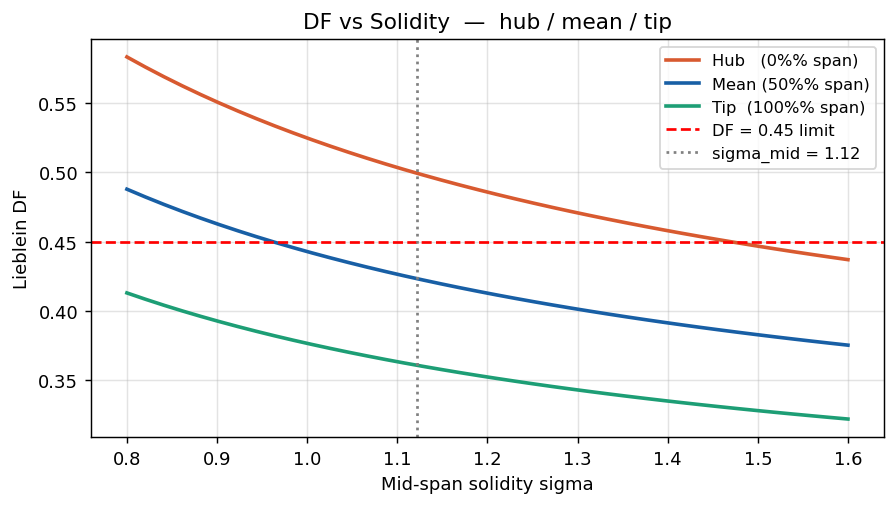

In [7]:
sigma_range = np.linspace(0.8, 1.6, 40)
df_hub  = [free_vortex(res, n_stations=20, sigma=s)['DF'][0]   for s in sigma_range]
df_mean = [free_vortex(res, n_stations=20, sigma=s)['DF'][10]  for s in sigma_range]
df_tip  = [free_vortex(res, n_stations=20, sigma=s)['DF'][-1]  for s in sigma_range]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sigma_range, df_hub,  '#D85A30', lw=2, label='Hub   (0%% span)')
ax.plot(sigma_range, df_mean, '#185FA5', lw=2, label='Mean (50%% span)')
ax.plot(sigma_range, df_tip,  '#1D9E75', lw=2, label='Tip  (100%% span)')
ax.axhline(0.45, color='red', ls='--', lw=1.5, label='DF = 0.45 limit')
ax.axvline(sigma_mid, color='gray', ls=':', lw=1.5,
           label='sigma_mid = %.2f' % sigma_mid)
ax.set(xlabel='Mid-span solidity sigma', ylabel='Lieblein DF',
       title='DF vs Solidity  —  hub / mean / tip')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(str(_root / 'figures' / '02_df_vs_sigma.png'), dpi=130, bbox_inches='tight')
plt.show()

---
**Proceed to** `03_igv_design.ipynb`.